## Chuẩn bị dữ liệu 

In [4]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
import pywt 

In [5]:
def display_images(*images, titles=None, max_cols=5):
    num_images = min(len(images), 16)  # Giới hạn tối đa 10 ảnh
    
    if num_images == 0:
        print("No images to display.")
        return
    
    # Tính toán số hàng và cột
    cols = min(num_images, max_cols)
    rows = (num_images + cols - 1) // cols
    
    # Tạo figure
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    # Ép kiểu axes thành mảng 1 chiều để dễ truy vấn trong vòng lặp
    if num_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    for i in range(num_images):
        img = images[i]
        
        # Kiểm tra nếu là ảnh xám (2D) hoặc ảnh màu (3D)
        if len(img.shape) == 2:
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].imshow(img)
            
        # Thiết lập tiêu đề
        title = titles[i] if titles and i < len(titles) else f"Image {i+1}"
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Ẩn các ô subplot dư thừa nếu có
    for i in range(num_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [6]:
img_1 = cv2.imread("/home/tuong/Courses/CV/Chap3/data/flower1_noise_0.05.jpg", 0)
img_2 = cv2.imread("/home/tuong/Courses/CV/Chap3/data/flower1_rotated_-15.jpg", 0)
img_3 = cv2.imread("/home/tuong/Courses/CV/Chap3/data/flower1_noise_0.05.jpg", 0)
img_4 = cv2.imread("/home/tuong/Courses/CV/Chap3/data/Kim_Yoo-jung.jpg", 0)

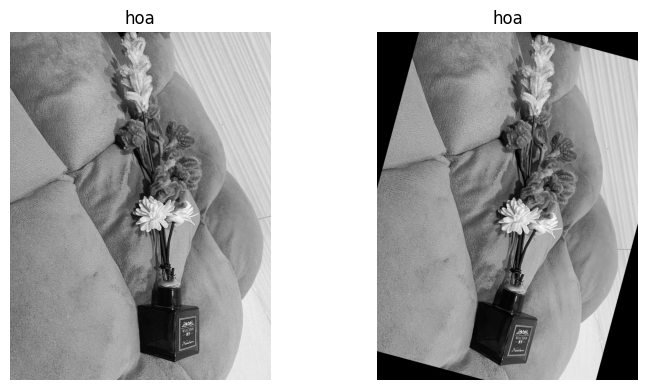

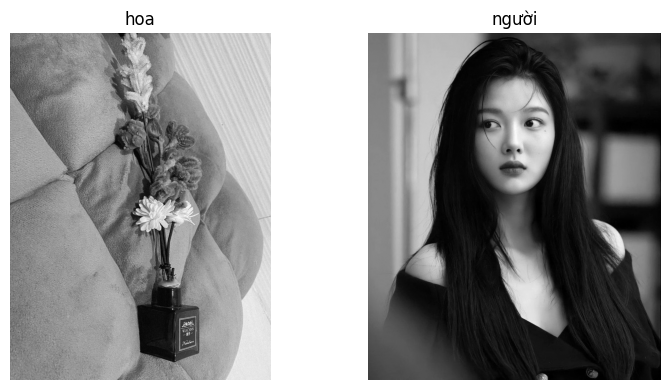

In [7]:
display_images(img_1, img_2, titles=["hoa", "hoa"])
display_images(img_3, img_4, titles=["hoa", "người"])

In [8]:
#áp dụng dwt (haar)
def wavelet(img):
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_gray = img

    # Áp dụng Discrete Wavelet Transform (DWT) 2D với wavelet 'haar'
    coeffs = pywt.dwt2(img_gray, 'haar')
    LL, (LH, HL, HH) = coeffs
    
    return LL, LH, HL, HH

In [9]:
LL1, LH1, HL1, HH1 = wavelet(img_1)
LL2, LH2, HL2, HH2 = wavelet(img_2)
LL3, LH3, HL3, HH3 = wavelet(img_3)
LL4, LH4, HL4, HH4 = wavelet(img_4)

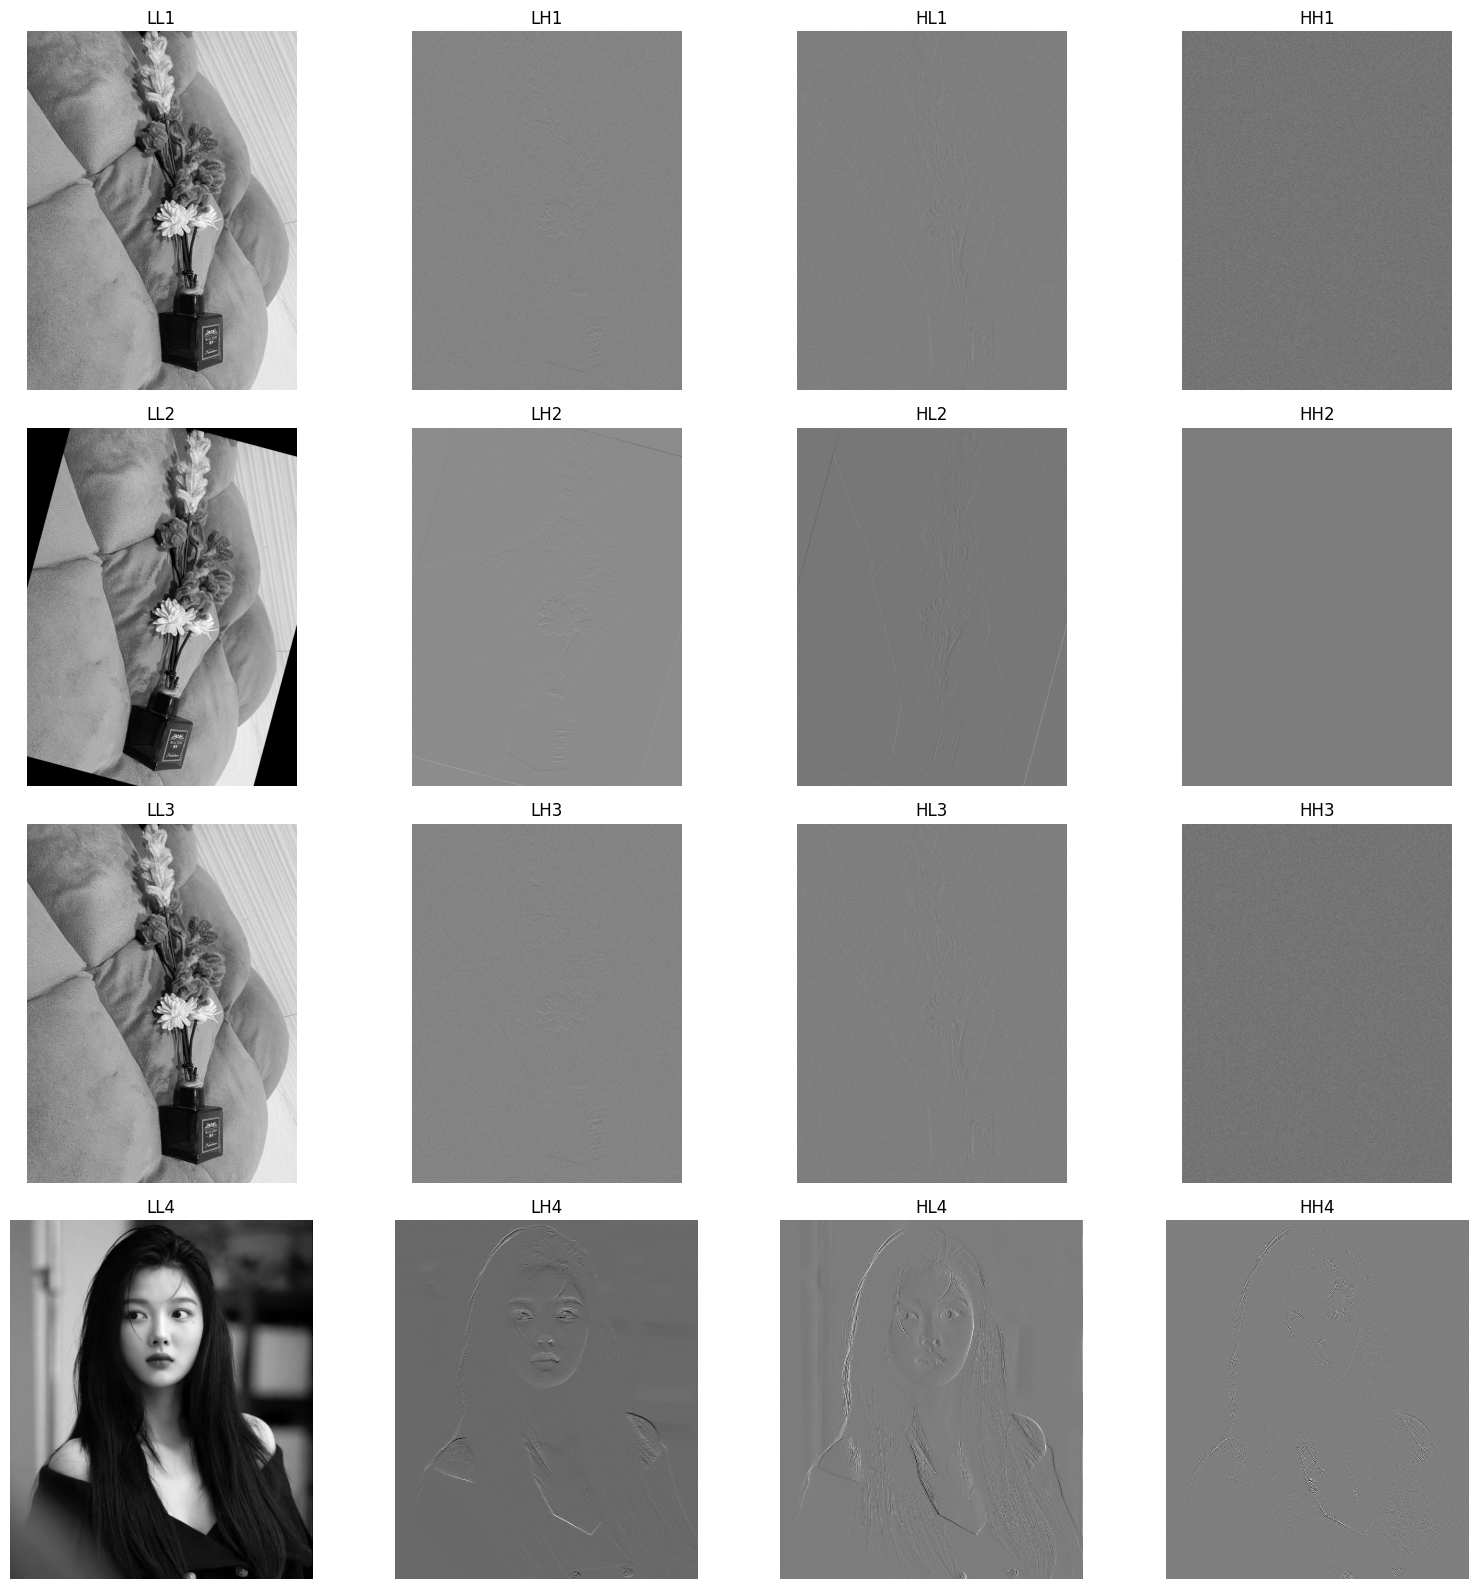

In [10]:
all_wavelet_subbands = [
    LL1, LH1, HL1, HH1, 
    LL2, LH2, HL2, HH2, 
    LL3, LH3, HL3, HH3, 
    LL4, LH4, HL4, HH4
]

tieu_de_full = [
    "LL1", "LH1", "HL1", "HH1",
    "LL2", "LH2", "HL2", "HH2",
    "LL3", "LH3", "HL3", "HH3",
    "LL4", "LH4", "HL4", "HH4"
]

display_images(*all_wavelet_subbands, titles=tieu_de_full, max_cols=4)

In [38]:
from sklearn.decomposition import PCA
def extract_feature(img):
    LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')

    feature = LL.flatten()

    # normalize
    feature = feature / np.linalg.norm(feature)
    value = feature
    print (value)
    return feature

"""def downsampling(feature):
    pca = PCA(n_components=256)
    X_reduced = pca.fit_transform([feature])
    return X_reduced[0]"""

def hash_feature(feature):
    mean = np.mean(feature)
    return (feature > mean).astype(int)


def process_image(img):
    img = cv2.resize(img, (84, 84))

    f = extract_feature(img)
    # d = downsampling(f)
    h = hash_feature(f)
    return h

feature_1 = process_image(img_1)
feature_2 = process_image(img_2)
feature_3 = process_image(img_3)
feature_4 = process_image(img_4)

print(feature_1.shape)

[0.01733192 0.01985787 0.01791483 ... 0.03684004 0.03629599 0.03672346]
[0. 0. 0. ... 0. 0. 0.]
[0.01733192 0.01985787 0.01791483 ... 0.03684004 0.03629599 0.03672346]
[0.02841736 0.02841736 0.02882236 ... 0.00215999 0.00236249 0.00027   ]
(1764,)


In [39]:
def hamming(a, b):
    return np.sum(a != b)

print("A vs B:", hamming(feature_1, feature_2))  
print("A vs B:", hamming(feature_3, feature_4))  

A vs B: 704
A vs B: 1151
